In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, median_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, log_loss, cohen_kappa_score,
    top_k_accuracy_score
)
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, BayesianRidge, ElasticNet, LogisticRegression
)
from sklearn.kernel_ridge import KernelRidge
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier




In [2]:
%cd ../DS_HW2
!ls

/home/aria/sharif/data_science/DS_HW2
data  dataset_analysis.pdf  Kaggle.py  my.Ipynb  README.md  requirements.txt


In [3]:
df = pd.read_csv("data/Teen_Mental_Health_Dataset.csv")


In [4]:
df_proc = df.copy()
df_proc['gender'] = LabelEncoder().fit_transform(df_proc['gender'])
df_proc['platform_usage'] = LabelEncoder().fit_transform(df_proc['platform_usage'])
le_social = LabelEncoder()
df_proc['social_interaction_level'] = le_social.fit_transform(df_proc['social_interaction_level'])
print(le_social.classes_)
df_proc.head()

['high' 'low' 'medium']


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,1,7.9,1,7.4,2.9,3.01,1.5,1,2,2,1,0
1,19,0,1.9,2,8.0,2.9,3.22,0.8,0,8,1,10,0
2,17,0,1.3,1,7.6,0.5,3.92,0.0,0,2,4,2,0
3,15,1,7.4,2,6.9,1.6,3.48,0.8,2,1,7,9,0
4,15,0,4.7,0,4.9,3.0,2.37,1.4,2,3,5,2,0


# Regression

In [5]:
reg_target = 'daily_social_media_hours'
X_reg = df_proc.drop(columns=[reg_target]).values
y_reg = df_proc[reg_target].values

X_rtr, X_rte, y_rtr, y_rte = train_test_split(X_reg, y_reg, test_size=0.1, random_state=42)
sc_r = StandardScaler()
X_rtr_s = sc_r.fit_transform(X_rtr)
X_rte_s = sc_r.transform(X_rte)

reg_res = {}

def reg_eval(name, yt, yp):
    mask = yt != 0
    ypc  = np.clip(yp, 0, None)
    d    = np.abs(yt - yp); dl = 1.0
    reg_res[name] = {
        'MSE'      : mean_squared_error(yt, yp),
        'MAE'      : mean_absolute_error(yt, yp),
        'MAPE'     : np.mean(np.abs((yt[mask] - yp[mask]) / yt[mask])) * 100,
        'R2'       : r2_score(yt, yp),
        'MedianAE' : median_absolute_error(yt, yp),
        'MSLE'     : np.mean((np.log1p(yt) - np.log1p(ypc))**2),
        'RMSLE'    : np.sqrt(np.mean((np.log1p(yt) - np.log1p(ypc))**2)),
        'Huber'    : np.mean(np.where(d <= dl, 0.5*d**2, dl*(d - 0.5*dl)))
    }

In [6]:
m = LinearRegression().fit(X_rtr_s, y_rtr)
reg_eval('Linear Regression', y_rte, m.predict(X_rte_s))

In [7]:
m = KernelRidge(kernel='rbf', alpha=1.0, gamma=0.1).fit(X_rtr_s, y_rtr)
reg_eval('Kernel Regression', y_rte, m.predict(X_rte_s))

In [8]:
m = Ridge(alpha=1.0).fit(X_rtr_s, y_rtr)
reg_eval('Ridge Regression', y_rte, m.predict(X_rte_s))

In [9]:
m = Lasso(alpha=0.1, max_iter=5000).fit(X_rtr_s, y_rtr)
reg_eval('LASSO', y_rte, m.predict(X_rte_s))

In [10]:
m = Lasso(alpha=0.1, max_iter=5000).fit(X_rtr_s, y_rtr)
reg_eval('LASSO', y_rte, m.predict(X_rte_s))

In [11]:
pf = PolynomialFeatures(degree=2, include_bias=False)
X_ptr = pf.fit_transform(X_rtr_s)
X_pte = pf.transform(X_rte_s)
m = Ridge(alpha=1.0).fit(X_ptr, y_rtr)
reg_eval('Polynomial Regression', y_rte, m.predict(X_pte))

In [12]:
m = BayesianRidge().fit(X_rtr_s, y_rtr)
reg_eval('Bayesian Ridge', y_rte, m.predict(X_rte_s))

In [13]:
m = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000).fit(X_rtr_s, y_rtr)
reg_eval('Elastic Net', y_rte, m.predict(X_rte_s))

In [14]:
m = DecisionTreeRegressor(max_depth=4, random_state=42).fit(X_rtr_s, y_rtr)
reg_eval('Decision Tree Regression', y_rte, m.predict(X_rte_s))

In [15]:
m = SVR(kernel='rbf', C=10, gamma='scale').fit(X_rtr_s, y_rtr)
reg_eval('SVR', y_rte, m.predict(X_rte_s))

In [16]:
def lwr_predict(X_tr, y_tr, X_te, tau=0.5):
    Xb = np.c_[np.ones(len(X_tr)), X_tr]
    preds = []
    for x in X_te:
        w = np.exp(-np.sum((X_tr - x)**2, axis=1) / (2 * tau**2))
        W = np.diag(w)
        theta = np.linalg.pinv(Xb.T @ W @ Xb) @ Xb.T @ W @ y_tr
        preds.append(np.r_[1, x] @ theta)
    return np.array(preds)

reg_eval('LWR', y_rte, lwr_predict(X_rtr_s, y_rtr, X_rte_s))

,MSE,MAE,MAPE,R2,MedianAE,MSLE,RMSLE,Huber
Linear Regression,3.4930,1.5648,53.7370,0.0457,1.4358,0.1523,0.3903,1.1285
Kernel Regression,3.9710,1.6594,52.2968,-0.0849,1.5664,0.1611,0.4014,1.2102
Ridge Regression,3.4931,1.5649,53.7377,0.0457,1.4357,0.1523,0.3903,1.1285
LASSO,3.4766,1.5608,53.5860,0.0502,1.5113,0.1517,0.3895,1.1273
Polynomial Regression,3.7340,1.6186,53.2255,-0.0201,1.5818,0.1560,0.3949,1.1835
Bayesian Ridge,3.5199,1.5694,53.9307,0.0384,1.4511,0.1533,0.3915,1.1358
Elastic Net,3.4645,1.5587,53.5014,0.0535,1.4754,0.1513,0.3890,1.1246
Decision Tree Regression,3.6283,1.6052,52.9683,0.0088,1.6500,0.1516,0.3893,1.1733
SVR,4.8976,1.8826,59.3373,-0.3380,1.8499,0.2030,0.4506,1.4235
LWR,13.3866,2.9261,86.0278,-2.6571,2.3477,0.5951,0.7714,2.4690


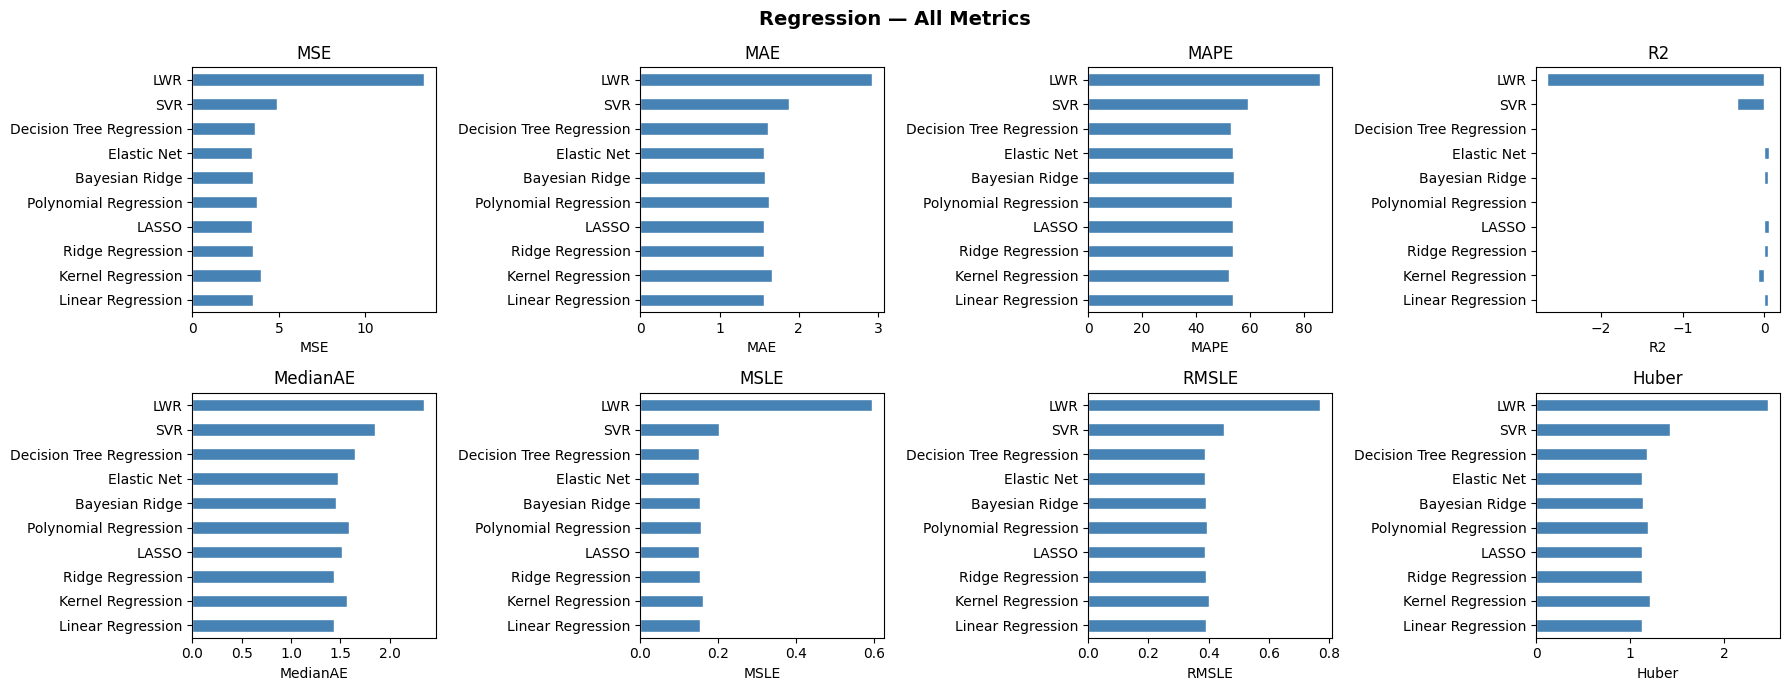

In [49]:
#Regression Results
reg_df = pd.DataFrame(reg_res).T.round(4)
display(reg_df)

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.flatten(), reg_df.columns):
    reg_df[col].plot(kind='barh', ax=ax, title=col, color='steelblue', edgecolor='white')
    ax.set_xlabel(col)
plt.suptitle('Regression — All Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Binary Classification

In [18]:
bin_target = 'depression_label'
X_bin = df_proc.drop(columns=[bin_target]).values
y_bin = df_proc[bin_target].values

X_btr, X_bte, y_btr, y_bte = train_test_split(X_bin, y_bin, test_size=0.1, random_state=42)
sc_b = StandardScaler()
X_btr_s = sc_b.fit_transform(X_btr)
X_bte_s = sc_b.transform(X_bte)

bin_res  = {}
roc_data = {}
cms      = {}

def bin_eval(name, model, Xte, yte):
    yp = model.predict(Xte)
    if hasattr(model, 'predict_proba'):
        ypr = model.predict_proba(Xte)[:, 1]
    elif hasattr(model, 'decision_function'):
        ypr = model.decision_function(Xte)
    else:
        ypr = yp.astype(float)

    cm = confusion_matrix(yte, yp)
    cms[name] = cm
    tn, fp, fn, tp = (cm.ravel() if cm.size == 4 else [0, 0, 0, 0])

    try:
        fpr, tpr, _ = roc_curve(yte, ypr)
        ra = auc(fpr, tpr)
    except Exception:
        fpr, tpr, ra = np.array([0, 1]), np.array([0, 1]), 0.5
    roc_data[name] = (fpr, tpr, ra)

    bin_res[name] = {
        'Accuracy'   : accuracy_score(yte, yp),
        'Precision'  : precision_score(yte, yp, zero_division=0),
        'Recall'     : recall_score(yte, yp, zero_division=0),
        'F1'         : f1_score(yte, yp, zero_division=0),
        'AUC'        : ra,
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
    }

In [19]:
m = LogisticRegression(max_iter=1000, random_state=42).fit(X_btr_s, y_btr)
bin_eval('Logistic Regression', m, X_bte_s, y_bte)

In [20]:
m = SVC(kernel='linear', probability=True, random_state=42).fit(X_btr_s, y_btr)
bin_eval('Linear SVM', m, X_bte_s, y_bte)

In [21]:
m = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42).fit(X_btr_s, y_btr)
bin_eval('Kernel SVM', m, X_bte_s, y_bte)

In [22]:
k_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X_btr_s, y_btr, cv=5, scoring='f1_weighted').mean()
            for k in range(1, 21)]
best_k = np.argmax(k_scores) + 1
print(f"Best K = {best_k}")
m = KNeighborsClassifier(n_neighbors=best_k).fit(X_btr_s, y_btr)
bin_eval('KNN', m, X_bte_s, y_bte)

Best K = 1


In [23]:
depth_scores = [cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=42),
                                 X_btr_s, y_btr, cv=5, scoring='f1_weighted').mean()
                for d in range(1, 21)]
best_depth = np.argmax(depth_scores) + 1
print(f"Best max_depth = {best_depth}")
m = DecisionTreeClassifier(max_depth=best_depth, random_state=42).fit(X_btr_s, y_btr)
bin_eval('Decision Tree', m, X_bte_s, y_bte)

Best max_depth = 8


In [24]:
m = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_btr_s, y_btr)
bin_eval('Random Forest', m, X_bte_s, y_bte)

In [25]:
m = LinearDiscriminantAnalysis().fit(X_btr_s, y_btr)
bin_eval('LDA', m, X_bte_s, y_bte)

In [26]:
m = GaussianNB().fit(X_btr_s, y_btr)
bin_eval('Naive Bayes', m, X_bte_s, y_bte)

In [27]:
bin_df = pd.DataFrame(bin_res).T.round(4)
display(bin_df)

,Accuracy,Precision,Recall,F1,AUC,Sensitivity,Specificity
Logistic Regression,0.9750,1.0000,0.4,0.5714,0.9930,0.4,1.0000
Linear SVM,0.9750,1.0000,0.4,0.5714,0.9913,0.4,1.0000
Kernel SVM,0.9583,0.5000,0.2,0.2857,0.9739,0.2,0.9913
KNN,0.9583,0.5000,0.2,0.2857,0.5957,0.2,0.9913
Decision Tree,0.9917,0.8333,1.0,0.9091,0.9957,1.0,0.9913
Random Forest,0.9583,0.0000,0.0,0.0000,0.9983,0.0,1.0000
LDA,0.9583,0.0000,0.0,0.0000,0.9826,0.0,1.0000
Naive Bayes,0.9833,1.0000,0.6,0.7500,0.9896,0.6,1.0000


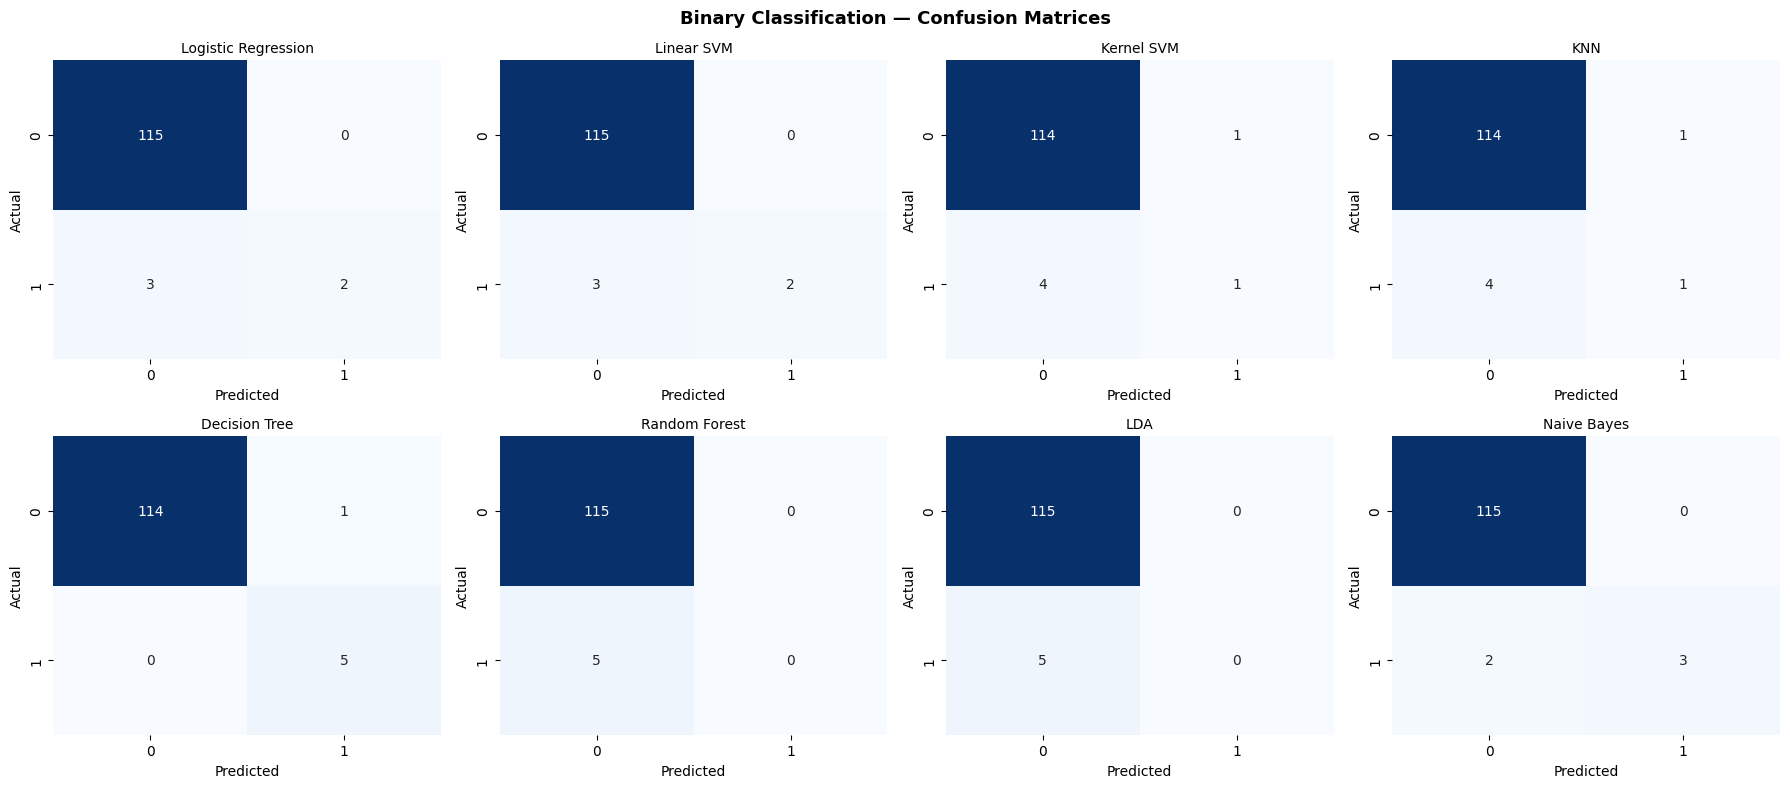

In [47]:
n = len(cms)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, (name, cm) in zip(axes.flatten(), cms.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Binary Classification — Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.show()

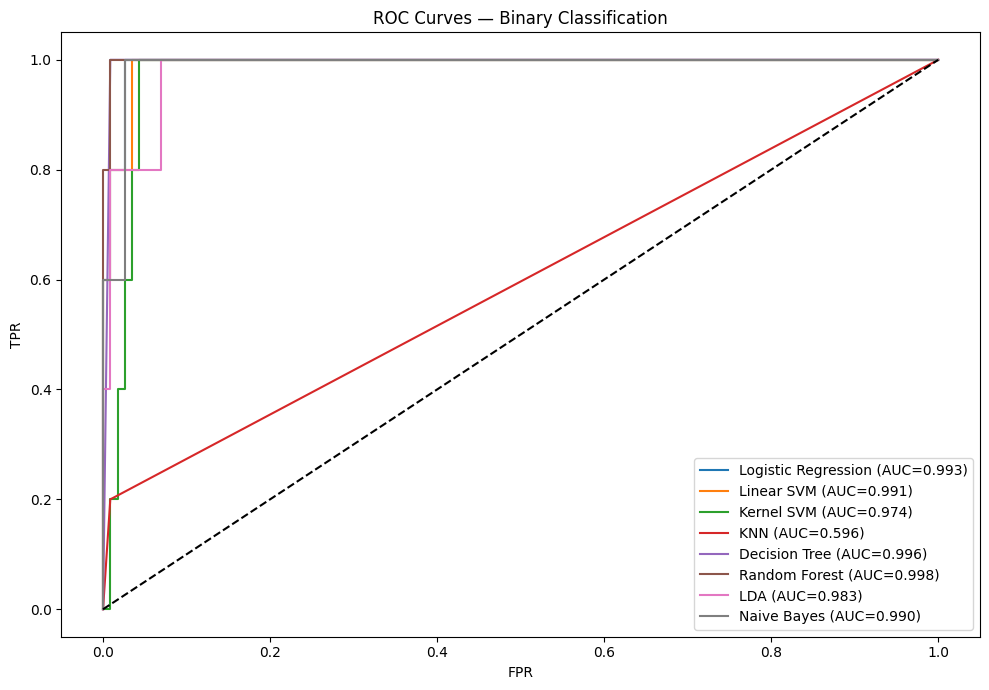

In [48]:
plt.figure(figsize=(10, 7))
for name, (fpr, tpr, ra) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC={ra:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curves — Binary Classification')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Multi Class Classification

In [30]:
mc_target = 'social_interaction_level'
X_mc = df_proc.drop(columns=[mc_target]).values
y_mc = df_proc[mc_target].values

X_mtr, X_mte, y_mtr, y_mte = train_test_split(X_mc, y_mc, test_size=0.1, random_state=42)
sc_m = StandardScaler()
X_mtr_s = sc_m.fit_transform(X_mtr)
X_mte_s = sc_m.transform(X_mte)

mc_res = {}

def mc_eval(name, model, Xte, yte):
    yp     = model.predict(Xte)
    n_cls  = len(np.unique(y_mc))
    acc    = accuracy_score(yte, yp)
    pre_pc = precision_score(yte, yp, average=None, zero_division=0)
    rec_pc = recall_score(yte, yp, average=None, zero_division=0)
    f1_mac = f1_score(yte, yp, average='macro', zero_division=0)
    f1_mic = f1_score(yte, yp, average='micro', zero_division=0)
    f1_wt  = f1_score(yte, yp, average='weighted', zero_division=0)
    kappa  = cohen_kappa_score(yte, yp)

    try:
        ypr  = model.predict_proba(Xte)
        ll   = log_loss(yte, ypr)
        top2 = top_k_accuracy_score(yte, ypr, k=min(2, n_cls - 1))
    except Exception:
        ll = top2 = np.nan

    mc_res[name] = {
        'Accuracy'   : acc,
        'F1_Macro'   : f1_mac,
        'F1_Micro'   : f1_mic,
        'F1_Weighted': f1_wt,
        'Kappa'      : kappa,
        'LogLoss'    : ll,
        'Top2_Acc'   : top2,
        'Prec_per_cls': pre_pc.tolist(),
        'Rec_per_cls' : rec_pc.tolist(),
    }

In [31]:
m = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42).fit(X_mtr_s, y_mtr)
mc_eval('SVM (OVO)', m, X_mte_s, y_mte)

In [32]:
m = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)).fit(X_mtr_s, y_mtr)
mc_eval('LR OVR', m, X_mte_s, y_mte)
print(f"LR OVR Log Loss: {mc_res['LR OVR']['LogLoss']:.4f}")

LR OVR Log Loss: 1.0975


In [33]:
m = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42).fit(X_mtr_s, y_mtr)
mc_eval('LR Multinomial', m, X_mte_s, y_mte)
print(f"LR Multinomial Log Loss: {mc_res['LR Multinomial']['LogLoss']:.4f}")

LR Multinomial Log Loss: 1.0974


In [34]:
k_scores_mc = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X_mtr_s, y_mtr,
                                cv=5, scoring='f1_weighted').mean()
               for k in range(1, 21)]
best_k_mc = np.argmax(k_scores_mc) + 1
print(f"Best K = {best_k_mc}")
m = KNeighborsClassifier(n_neighbors=best_k_mc).fit(X_mtr_s, y_mtr)
mc_eval('KNN', m, X_mte_s, y_mte)

Best K = 19


In [35]:
depth_scores_mc = [cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=42),
                                    X_mtr_s, y_mtr, cv=5, scoring='f1_weighted').mean()
                   for d in range(1, 21)]
best_d_mc = np.argmax(depth_scores_mc) + 1
print(f"Best max_depth = {best_d_mc}")
m = DecisionTreeClassifier(max_depth=best_d_mc, random_state=42).fit(X_mtr_s, y_mtr)
mc_eval('Decision Tree', m, X_mte_s, y_mte)

Best max_depth = 16


In [36]:
n_cls = len(np.unique(y_mc))
m = XGBClassifier(
    objective='multi:softprob', num_class=n_cls,
    n_estimators=200, learning_rate=0.1,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=42, verbosity=0
).fit(X_mtr_s, y_mtr)
mc_eval('XGBoost', m, X_mte_s, y_mte)

In [37]:
m = LGBMClassifier(n_estimators=200, learning_rate=0.1, random_state=42, verbose=-1).fit(X_mtr_s, y_mtr)
mc_eval('LightGBM', m, X_mte_s, y_mte)

In [38]:
m = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=100,
    random_state=42
).fit(X_mtr_s, y_mtr)

mc_eval('AdaBoost', m, X_mte_s, y_mte)

In [39]:
m = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_mtr_s, y_mtr)
mc_eval('Random Forest', m, X_mte_s, y_mte)

In [40]:
estimators = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=best_k_mc))
]
m = VotingClassifier(estimators=estimators, voting='soft').fit(X_mtr_s, y_mtr)
mc_eval('Voting Classifier', m, X_mte_s, y_mte)

In [41]:
scalar_cols = ['Accuracy', 'F1_Macro', 'F1_Micro', 'F1_Weighted', 'Kappa', 'LogLoss', 'Top2_Acc']
mc_df = pd.DataFrame({k: {c: v for c, v in mc_res[k].items() if c in scalar_cols}
                       for k in mc_res}).T.round(4)
display(mc_df)

print("\n--- Precision per class ---")
for name in mc_res:
    print(f"{name:20s}: {[round(x,3) for x in mc_res[name]['Prec_per_cls']]}")

print("\n--- Recall per class ---")
for name in mc_res:
    print(f"{name:20s}: {[round(x,3) for x in mc_res[name]['Rec_per_cls']]}")

,Accuracy,F1_Macro,F1_Micro,F1_Weighted,Kappa,LogLoss,Top2_Acc
SVM (OVO),0.3333,0.3253,0.3333,0.3230,-0.0009,1.0982,0.7167
LR OVR,0.3917,0.3779,0.3917,0.3866,0.0762,1.0975,0.7083
LR Multinomial,0.3833,0.3703,0.3833,0.3784,0.0636,1.0974,0.7083
KNN,0.3417,0.3331,0.3417,0.3388,0.0088,1.1546,0.6750
Decision Tree,0.3000,0.2978,0.3000,0.2993,-0.0520,23.8185,0.6667
XGBoost,0.3333,0.3166,0.3333,0.3260,-0.0104,1.4218,0.6417
LightGBM,0.3833,0.3656,0.3833,0.3761,0.0645,1.7413,0.6667
AdaBoost,0.3750,0.3663,0.3750,0.3703,0.0536,1.0990,0.7167
Random Forest,0.3500,0.3333,0.3500,0.3433,0.0120,1.1231,0.6917
Voting Classifier,0.3667,0.3519,0.3667,0.3611,0.0383,1.1137,0.6750



--- Precision per class ---
SVM (OVO)           : [0.333, 0.345, 0.308]
LR OVR              : [0.296, 0.422, 0.417]
LR Multinomial      : [0.296, 0.4, 0.417]
KNN                 : [0.25, 0.357, 0.429]
Decision Tree       : [0.263, 0.306, 0.326]
XGBoost             : [0.207, 0.404, 0.333]
LightGBM            : [0.25, 0.46, 0.381]
AdaBoost            : [0.333, 0.44, 0.325]
Random Forest       : [0.231, 0.365, 0.405]
Voting Classifier   : [0.259, 0.377, 0.425]

--- Recall per class ---
SVM (OVO)           : [0.382, 0.442, 0.186]
LR OVR              : [0.235, 0.442, 0.465]
LR Multinomial      : [0.235, 0.419, 0.465]
KNN                 : [0.265, 0.465, 0.279]
Decision Tree       : [0.294, 0.256, 0.349]
XGBoost             : [0.176, 0.488, 0.302]
LightGBM            : [0.206, 0.535, 0.372]
AdaBoost            : [0.294, 0.512, 0.302]
Random Forest       : [0.176, 0.442, 0.395]
Voting Classifier   : [0.206, 0.465, 0.395]
